# Notebook 2: Non-IB Customer — Exploratory Data Analysis (EDA)

**G'CONTEST 2026 — Phân tích nhóm khách hàng chưa đăng ký Internet Banking**

Mục tiêu:
- Hiểu phân phối dữ liệu và phát hiện patterns
- Xác định outliers và quyết định xử lý
- Kiểm tra correlation giữa features
- Phân tích product penetration matrix
- Validate dữ liệu trước khi đưa vào clustering

**Input:** `output/nonib_master.parquet` (từ Notebook 1)

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('viridis', 8)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'Cluster_nonIB':
    PROJECT_DIR = PROJECT_DIR.parent

CLUSTER_DIR = PROJECT_DIR / 'Cluster_nonIB'
OUTPUT_DIR = CLUSTER_DIR / 'output'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Ready.')

Ready.


In [2]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_parquet(OUTPUT_DIR / 'nonib_master.parquet')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head())

Shape: (127000, 51)
Columns: ['CUSTOMER_NUMBER', 'AGE', 'AGE_GROUP', 'TENURE_DAYS', 'CLIENT_SEX', 'SEX_F', 'SEX_M', 'CA_BALANCE_MEAN', 'CA_BALANCE_MAX', 'CA_BALANCE_MIN', 'CA_BALANCE_LAST', 'CA_BALANCE_STD', 'TD_BALANCE_MEAN', 'TD_BALANCE_MAX', 'TD_BALANCE_LAST', 'TD_BALANCE_STD', 'CA_ACCT_MAX', 'TD_ACCT_MAX', 'MONTHS_WITH_DEPOSIT', 'CA_BALANCE_TREND', 'TD_BALANCE_TREND', 'CA_TREND_DIRECTION', 'TD_TREND_DIRECTION', 'TD_TO_TOTAL_RATIO', 'HAS_CA', 'HAS_TD', 'DEPOSIT_DIVERSITY', 'CREDITCARD_MAX', 'DEBITCARD_MAX', 'MONTHS_WITH_CARD', 'HAS_CREDIT_CARD', 'HAS_DEBIT_CARD', 'CARD_DIVERSITY', 'LOAN_AMOUNT_MEAN', 'LOAN_AMOUNT_MAX', 'LOAN_AMOUNT_LAST', 'LOAN_AMOUNT_STD', 'LOAN_COUNT_MAX', 'MONTHS_WITH_LOAN', 'LOAN_TREND', 'HAS_LOAN', 'LOAN_TREND_DIRECTION', 'PRODUCT_COUNT', 'TOTAL_DEPOSIT', 'TOTAL_FINANCIAL_VALUE', 'NET_WORTH_PROXY', 'SAVINGS_RATE', 'IS_BORROWER_ONLY', 'IS_SAVER_ONLY', 'IS_DORMANT', 'MAX_ENGAGEMENT_MONTHS']


,CUSTOMER_NUMBER,AGE,AGE_GROUP,TENURE_DAYS,CLIENT_SEX,SEX_F,SEX_M,CA_BALANCE_MEAN,CA_BALANCE_MAX,CA_BALANCE_MIN,CA_BALANCE_LAST,CA_BALANCE_STD,TD_BALANCE_MEAN,TD_BALANCE_MAX,TD_BALANCE_LAST,TD_BALANCE_STD,CA_ACCT_MAX,TD_ACCT_MAX,MONTHS_WITH_DEPOSIT,CA_BALANCE_TREND,TD_BALANCE_TREND,CA_TREND_DIRECTION,TD_TREND_DIRECTION,TD_TO_TOTAL_RATIO,HAS_CA,...,DEPOSIT_DIVERSITY,CREDITCARD_MAX,DEBITCARD_MAX,MONTHS_WITH_CARD,HAS_CREDIT_CARD,HAS_DEBIT_CARD,CARD_DIVERSITY,LOAN_AMOUNT_MEAN,LOAN_AMOUNT_MAX,LOAN_AMOUNT_LAST,LOAN_AMOUNT_STD,LOAN_COUNT_MAX,MONTHS_WITH_LOAN,LOAN_TREND,HAS_LOAN,LOAN_TREND_DIRECTION,PRODUCT_COUNT,TOTAL_DEPOSIT,TOTAL_FINANCIAL_VALUE,NET_WORTH_PROXY,SAVINGS_RATE,IS_BORROWER_ONLY,IS_SAVER_ONLY,IS_DORMANT,MAX_ENGAGEMENT_MONTHS
0,62117,44.035592,35-45,309,M,0,1,0.000000e+00,0.00,0.00,0.00,0.000000,3.308337e+08,370000000.0,370000000.0,1.055436e+08,0.0,2.0,11.0,0.000000,1.883536e+07,0.0,1.0,1.0,0,...,1.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0,0.0,1,3.308337e+08,3.308337e+08,3.308337e+08,1.0,0,1,0,11.0
1,900734,36.566735,35-45,6,F,1,0,0.000000e+00,0.00,0.00,0.00,0.000000,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0,0.0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0,0,1,0.0
2,248998,38.261465,35-45,40,M,0,1,1.032446e+06,1032446.39,1032446.39,1032446.39,0.000000,0.000000e+00,0.0,0.0,0.000000e+00,1.0,0.0,1.0,0.000000,0.000000e+00,0.0,0.0,0.0,1,...,1.0,0.0,1.0,2.0,0,1,1.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0,0.0,2,1.032446e+06,1.032446e+06,1.032446e+06,0.0,0,0,0,2.0
3,954356,21.311431,<25,292,M,0,1,2.133808e+04,124203.87,556.00,27857.00,40264.245056,0.000000e+00,0.0,0.0,0.000000e+00,1.0,0.0,9.0,-4765.113333,0.000000e+00,-1.0,0.0,0.0,1,...,1.0,0.0,0.0,0.0,0,0,0.0,18597224.0,33475000.0,3719448.0,1.018612e+07,1.0,9.0,-3719444.0,1,-1.0,2,2.133808e+04,1.861856e+07,-1.857589e+07,0.0,0,0,0,9.0
4,671766,34.499658,25-35,55,M,0,1,2.166667e+05,250000.00,183333.33,250000.00,47140.454436,0.000000e+00,0.0,0.0,0.000000e+00,1.0,0.0,2.0,66666.670000,0.000000e+00,1.0,0.0,0.0,1,...,1.0,0.0,0.0,0.0,0,0,0.0,270000000.0,270000000.0,270000000.0,0.000000e+00,1.0,2.0,0.0,1,0.0,2,2.166667e+05,2.702167e+08,-2.697833e+08,0.0,0,0,0,2.0


---
## 1. Overview Statistics

In [3]:
# Missing values and zero-value percentages
overview = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'zero_pct': ((df == 0).sum() / len(df) * 100).round(2),
    'nunique': df.nunique(),
})
display(overview)

print(f'\nDescriptive statistics (numeric only):')
display(df.describe().round(2))

,dtype,non_null,null_pct,zero_pct,nunique
CUSTOMER_NUMBER,int32,127000,0.0,0.00,127000
AGE,float64,127000,0.0,0.00,19038
AGE_GROUP,category,127000,0.0,0.00,5
TENURE_DAYS,int64,127000,0.0,0.00,346
CLIENT_SEX,object,127000,0.0,0.00,2
SEX_F,int8,127000,0.0,49.76,2
SEX_M,int8,127000,0.0,50.24,2
CA_BALANCE_MEAN,float64,127000,0.0,37.48,74400
CA_BALANCE_MAX,float64,127000,0.0,37.48,66359
CA_BALANCE_MIN,float64,127000,0.0,42.82,44719



Descriptive statistics (numeric only):


,CUSTOMER_NUMBER,AGE,TENURE_DAYS,SEX_F,SEX_M,CA_BALANCE_MEAN,CA_BALANCE_MAX,CA_BALANCE_MIN,CA_BALANCE_LAST,CA_BALANCE_STD,TD_BALANCE_MEAN,TD_BALANCE_MAX,TD_BALANCE_LAST,TD_BALANCE_STD,CA_ACCT_MAX,TD_ACCT_MAX,MONTHS_WITH_DEPOSIT,CA_BALANCE_TREND,TD_BALANCE_TREND,CA_TREND_DIRECTION,TD_TREND_DIRECTION,TD_TO_TOTAL_RATIO,HAS_CA,HAS_TD,DEPOSIT_DIVERSITY,CREDITCARD_MAX,DEBITCARD_MAX,MONTHS_WITH_CARD,HAS_CREDIT_CARD,HAS_DEBIT_CARD,CARD_DIVERSITY,LOAN_AMOUNT_MEAN,LOAN_AMOUNT_MAX,LOAN_AMOUNT_LAST,LOAN_AMOUNT_STD,LOAN_COUNT_MAX,MONTHS_WITH_LOAN,LOAN_TREND,HAS_LOAN,LOAN_TREND_DIRECTION,PRODUCT_COUNT,TOTAL_DEPOSIT,TOTAL_FINANCIAL_VALUE,NET_WORTH_PROXY,SAVINGS_RATE,IS_BORROWER_ONLY,IS_SAVER_ONLY,IS_DORMANT,MAX_ENGAGEMENT_MONTHS
count,127000.00,127000.00,127000.00,127000.0,127000.0,127000.00,127000.00,127000.00,127000.00,127000.00,1.270000e+05,1.270000e+05,1.270000e+05,1.270000e+05,127000.00,127000.00,127000.00,127000.00,1.270000e+05,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,127000.00,1.270000e+05,1.270000e+05,1.270000e+05,1.270000e+05,127000.00,127000.00,1.270000e+05,127000.00,127000.00,127000.00,1.270000e+05,1.270000e+05,1.270000e+05,127000.0,127000.00,127000.0,127000.00,127000.00
mean,499475.46,38.81,180.36,0.5,0.5,926985.79,2085304.03,284081.86,924534.57,737444.26,3.813440e+07,5.337705e+07,4.050139e+07,1.496987e+07,0.63,0.28,4.05,21017.03,4.629609e+06,0.19,0.08,0.21,0.63,0.21,0.83,0.04,0.27,2.01,0.04,0.26,0.30,1.269859e+08,1.335544e+08,1.246518e+08,5.742866e+06,0.32,1.72,-6.311713e+05,0.29,-0.18,1.42,3.906139e+07,1.660472e+08,-8.792446e+07,0.2,0.04,0.2,0.19,4.82
std,288536.83,12.92,100.44,0.5,0.5,3864558.16,7772271.06,2494437.40,4398934.06,3053122.74,1.293038e+08,1.694265e+08,1.454450e+08,5.783638e+07,0.49,0.67,3.68,2011812.24,4.673967e+07,0.74,0.41,0.40,0.48,0.41,0.61,0.21,0.47,3.54,0.19,0.44,0.46,3.173156e+08,3.318696e+08,3.176496e+08,3.543348e+07,0.54,3.23,2.130337e+07,0.45,0.44,0.83,1.293607e+08,3.336736e+08,3.514381e+08,0.4,0.19,0.4,0.40,3.75
min,4.00,18.00,1.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,-68224780.79,-1.000000e+09,-1.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,-9.140992e+08,0.00,-1.00,0.00,0.000000e+00,0.000000e+00,-2.828198e+09,0.0,0.00,0.0,0.00,0.00
25%,249835.25,28.86,97.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,0.000000e+00,0.00,0.00,1.00,0.000000e+00,3.723500e+02,-2.375168e+07,0.0,0.00,0.0,0.00,1.00
50%,499715.00,36.66,177.00,1.0,0.0,77419.35,119077.37,7501.55,41000.00,18759.97,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.00,0.00,4.00,0.00,0.000000e+00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00,0.000000e+00,0.00,0.00,2.00,2.864357e+05,3.273182e+06,0.000000e+00,0.0,0.00,0.0,0.00,5.00
75%,748475.00,47.32,266.00,1.0,1.0,446020.14,939878.34,95602.33,327868.40,298278.56,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.00,0.00,7.00,20363.81,0.000000e+00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,3.00,0.00,1.00,1.00,2.629537e+07,3.570000e+07,2.100000e+07,0.000000e+00,1.00,2.00,0.000000e+00,1.00,0.00,2.00,3.448222e+06,2.178471e+08,1.530254e+06,0.0,0.00,0.0,0.00,8.00
max,999993.00,99.00,364.00,1.0,1.0,68224780.79,68224780.79,68224780.79,68224780.79,48242205.14,1.000000e+09,1.000000e+09,1.000000e+09,7.071068e+08,3.00,15.00,12.00,68224780.79,1.000000e+09,1.00,1.00,1.00,1.00,1.00,2.00,13.00,5.00,12.00,1.00,1.00,2.00,2.828198e+09,2.828198e+09,2.828198e+09,1.646285e+09,11.00,12.00,2.328198e+09,1.00,1.00,5.00,1.068225e+09,3.896423e+09,1.062644e+09,1.0,1.00,1.0,1.00,12.00


---
## 2. Univariate Analysis — Demographics

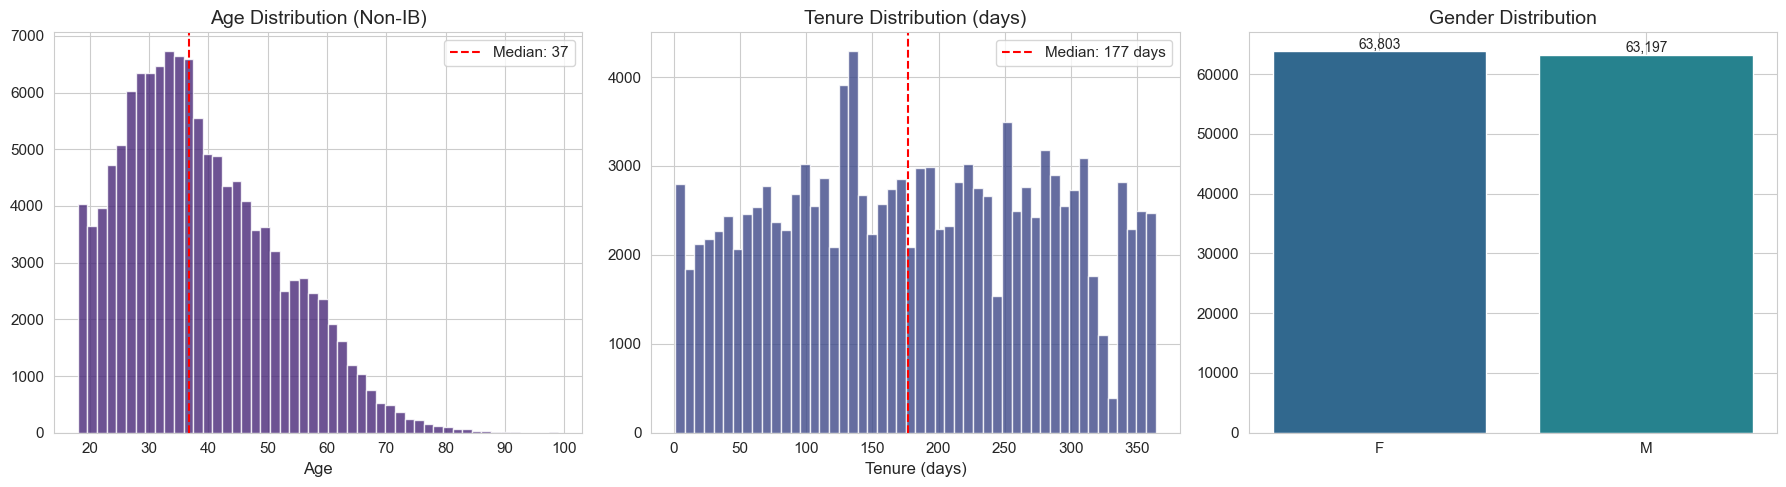

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(df['AGE'], bins=50, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].axvline(df['AGE'].median(), color='red', linestyle='--', label=f'Median: {df["AGE"].median():.0f}')
axes[0].set_title('Age Distribution (Non-IB)')
axes[0].set_xlabel('Age')
axes[0].legend()

# Tenure distribution
axes[1].hist(df['TENURE_DAYS'], bins=50, color=PALETTE[1], edgecolor='white', alpha=0.8)
axes[1].axvline(df['TENURE_DAYS'].median(), color='red', linestyle='--', label=f'Median: {df["TENURE_DAYS"].median():.0f} days')
axes[1].set_title('Tenure Distribution (days)')
axes[1].set_xlabel('Tenure (days)')
axes[1].legend()

# Gender
gender_counts = df['CLIENT_SEX'].value_counts()
axes[2].bar(gender_counts.index, gender_counts.values, color=[PALETTE[2], PALETTE[3], PALETTE[4]])
axes[2].set_title('Gender Distribution')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'demographics.png', dpi=150, bbox_inches='tight')
plt.show()

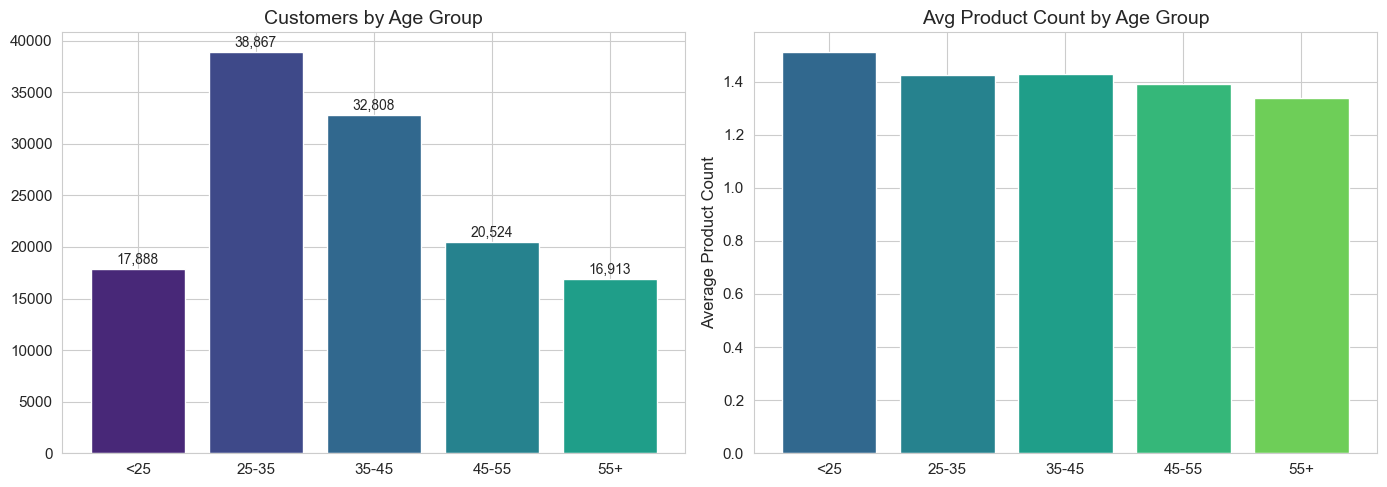

In [5]:
# Age group breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ag_counts = df['AGE_GROUP'].value_counts().sort_index()
bars = axes[0].bar(ag_counts.index.astype(str), ag_counts.values, color=PALETTE[:5])
axes[0].set_title('Customers by Age Group')
for bar, v in zip(bars, ag_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 500, f'{v:,}', ha='center', fontsize=10)

# Product count by age group
age_prod = df.groupby('AGE_GROUP')['PRODUCT_COUNT'].mean()
axes[1].bar(age_prod.index.astype(str), age_prod.values, color=PALETTE[2:7])
axes[1].set_title('Avg Product Count by Age Group')
axes[1].set_ylabel('Average Product Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'age_product.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Univariate Analysis — Financial Features

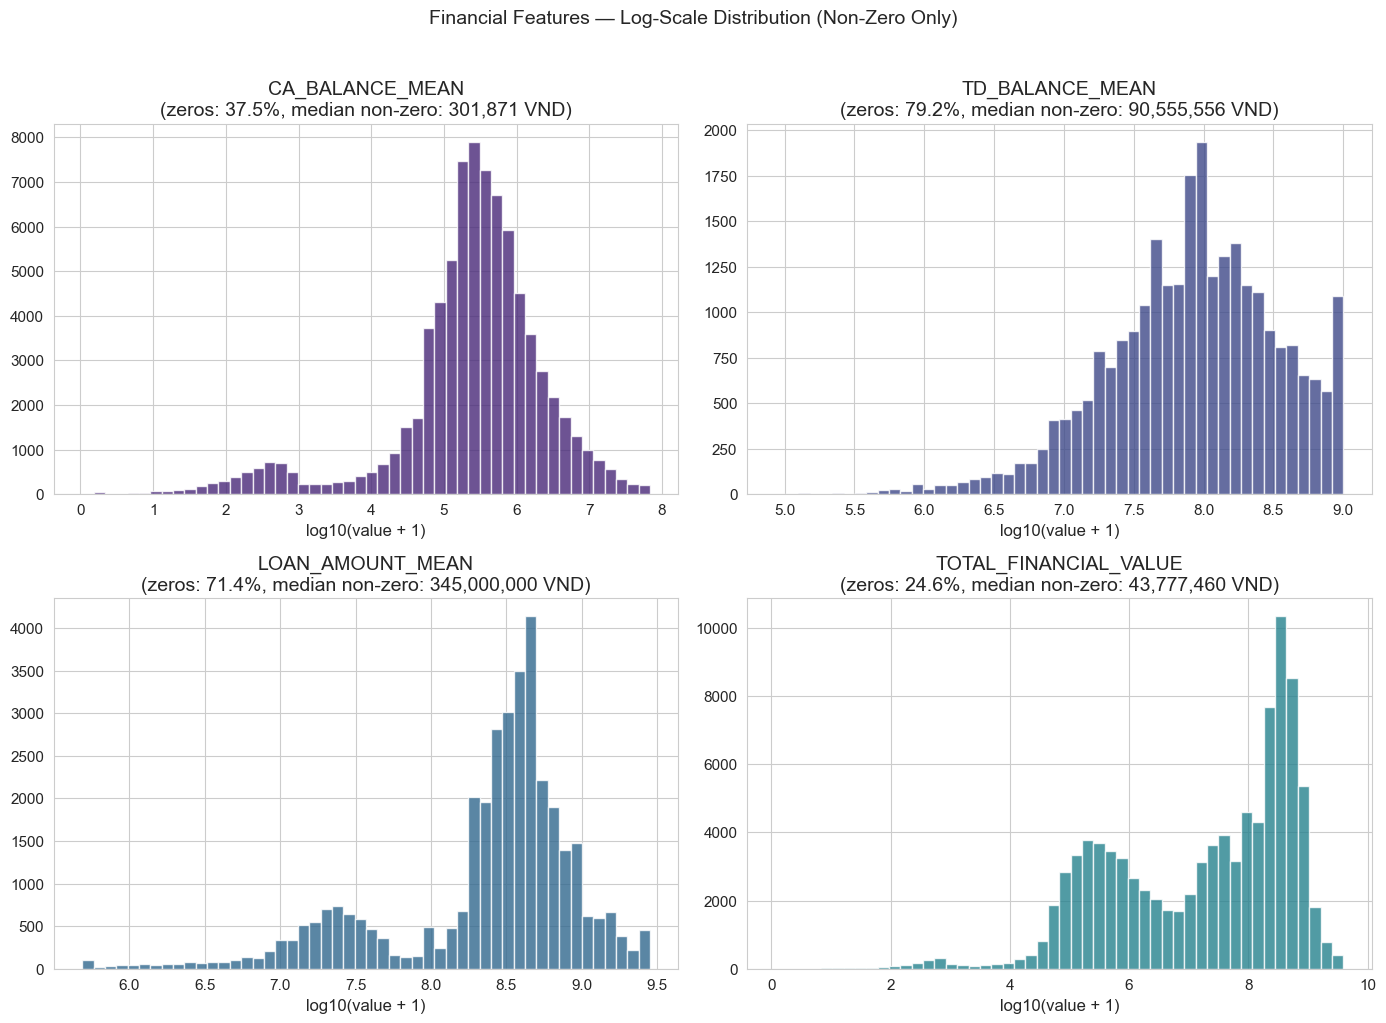

In [6]:
# Monetary features — log-scale distribution
monetary_cols = ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'LOAN_AMOUNT_MEAN', 'TOTAL_FINANCIAL_VALUE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(monetary_cols):
    data = df[col]
    # Only plot non-zero values on log scale
    nonzero = data[data > 0]
    if len(nonzero) > 0:
        axes[i].hist(np.log10(nonzero + 1), bins=50, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.8)
        axes[i].set_xlabel('log10(value + 1)')
    else:
        axes[i].text(0.5, 0.5, 'All zeros', ha='center', va='center', transform=axes[i].transAxes)
    zero_pct = (data == 0).mean() * 100
    axes[i].set_title(f'{col}\n(zeros: {zero_pct:.1f}%, median non-zero: {nonzero.median():,.0f} VND)' if len(nonzero) > 0 else col)

plt.suptitle('Financial Features — Log-Scale Distribution (Non-Zero Only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'financial_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

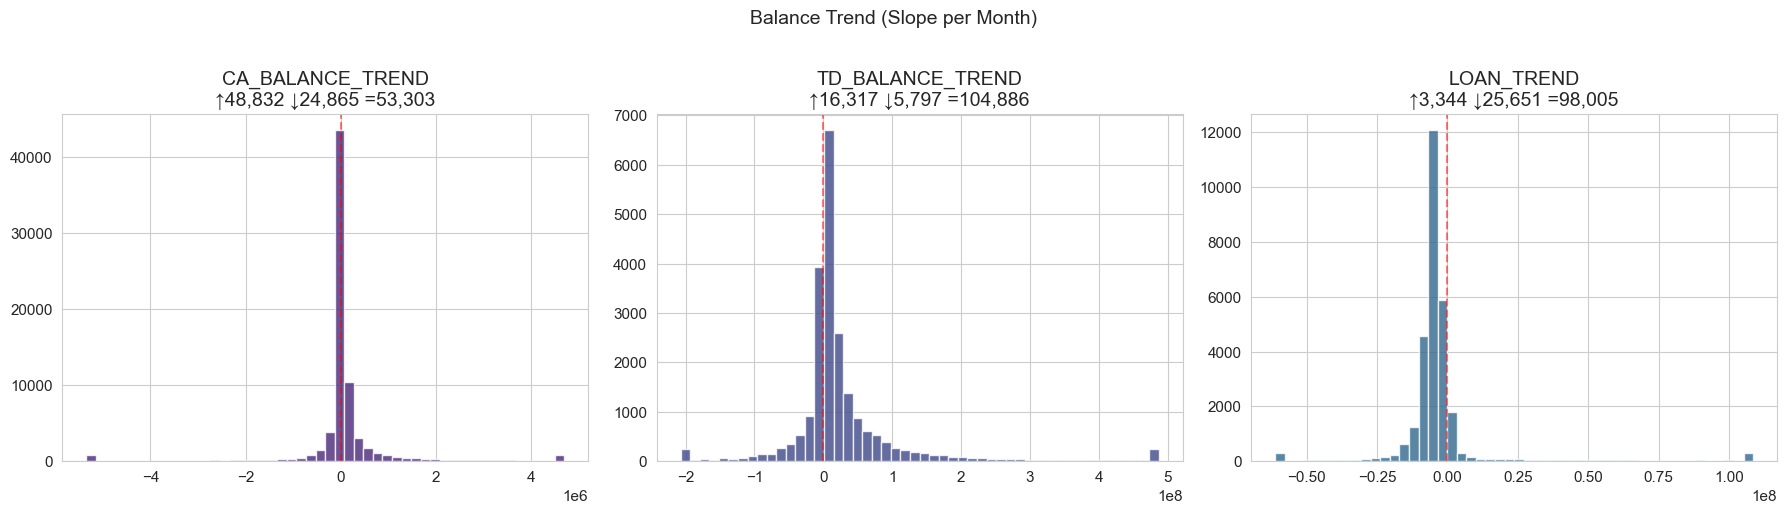

In [7]:
# Trend features distribution
trend_cols = ['CA_BALANCE_TREND', 'TD_BALANCE_TREND', 'LOAN_TREND']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(trend_cols):
    data = df[col]
    nonzero = data[data != 0]
    if len(nonzero) > 0:
        # Clip for visualization
        clipped = nonzero.clip(lower=nonzero.quantile(0.01), upper=nonzero.quantile(0.99))
        axes[i].hist(clipped, bins=50, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.8)
    increasing = (data > 0).sum()
    decreasing = (data < 0).sum()
    stable = (data == 0).sum()
    axes[i].set_title(f'{col}\n↑{increasing:,} ↓{decreasing:,} ={stable:,}')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Balance Trend (Slope per Month)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Product Penetration Matrix

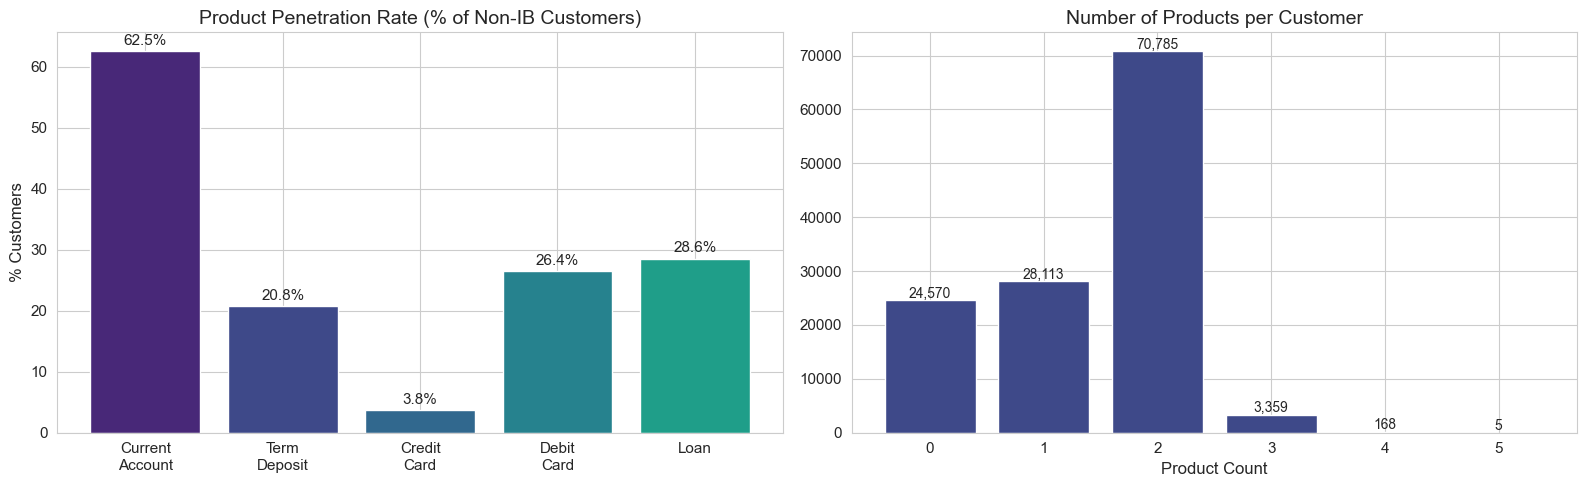

In [8]:
# Product ownership flags
product_cols = ['HAS_CA', 'HAS_TD', 'HAS_CREDIT_CARD', 'HAS_DEBIT_CARD', 'HAS_LOAN']
product_labels = ['Current\nAccount', 'Term\nDeposit', 'Credit\nCard', 'Debit\nCard', 'Loan']

# Bar chart of penetration
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Penetration rates
penetration = df[product_cols].mean() * 100
bars = axes[0].bar(product_labels, penetration.values, color=PALETTE[:5])
axes[0].set_title('Product Penetration Rate (% of Non-IB Customers)')
axes[0].set_ylabel('% Customers')
for bar, v in zip(bars, penetration.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

# Product count distribution
pc_counts = df['PRODUCT_COUNT'].value_counts().sort_index()
bars2 = axes[1].bar(pc_counts.index.astype(str), pc_counts.values, color=PALETTE[1])
axes[1].set_title('Number of Products per Customer')
axes[1].set_xlabel('Product Count')
for bar, v in zip(bars2, pc_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'product_penetration.png', dpi=150, bbox_inches='tight')
plt.show()

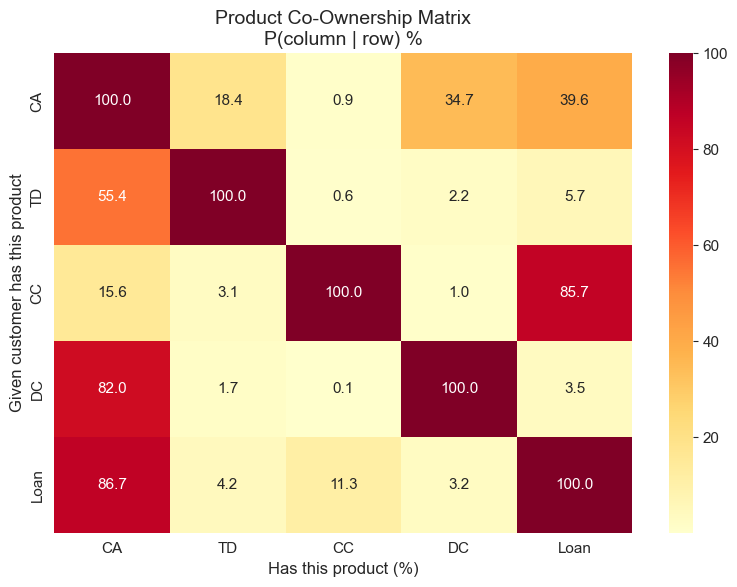

In [9]:
# Co-ownership heatmap
# For each product pair: P(has B | has A)
co_own = pd.DataFrame(index=product_cols, columns=product_cols, dtype='float64')

for prod_a in product_cols:
    has_a = df[prod_a] == 1
    count_a = has_a.sum()
    for prod_b in product_cols:
        if count_a > 0:
            co_own.loc[prod_a, prod_b] = (df.loc[has_a, prod_b] == 1).sum() / count_a * 100
        else:
            co_own.loc[prod_a, prod_b] = 0.0

co_own = co_own.astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    co_own, annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=['CA', 'TD', 'CC', 'DC', 'Loan'],
    yticklabels=['CA', 'TD', 'CC', 'DC', 'Loan'],
    ax=ax
)
ax.set_title('Product Co-Ownership Matrix\nP(column | row) %')
ax.set_xlabel('Has this product (%)')
ax.set_ylabel('Given customer has this product')
plt.tight_layout()
plt.savefig(FIG_DIR / 'co_ownership.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Correlation Analysis

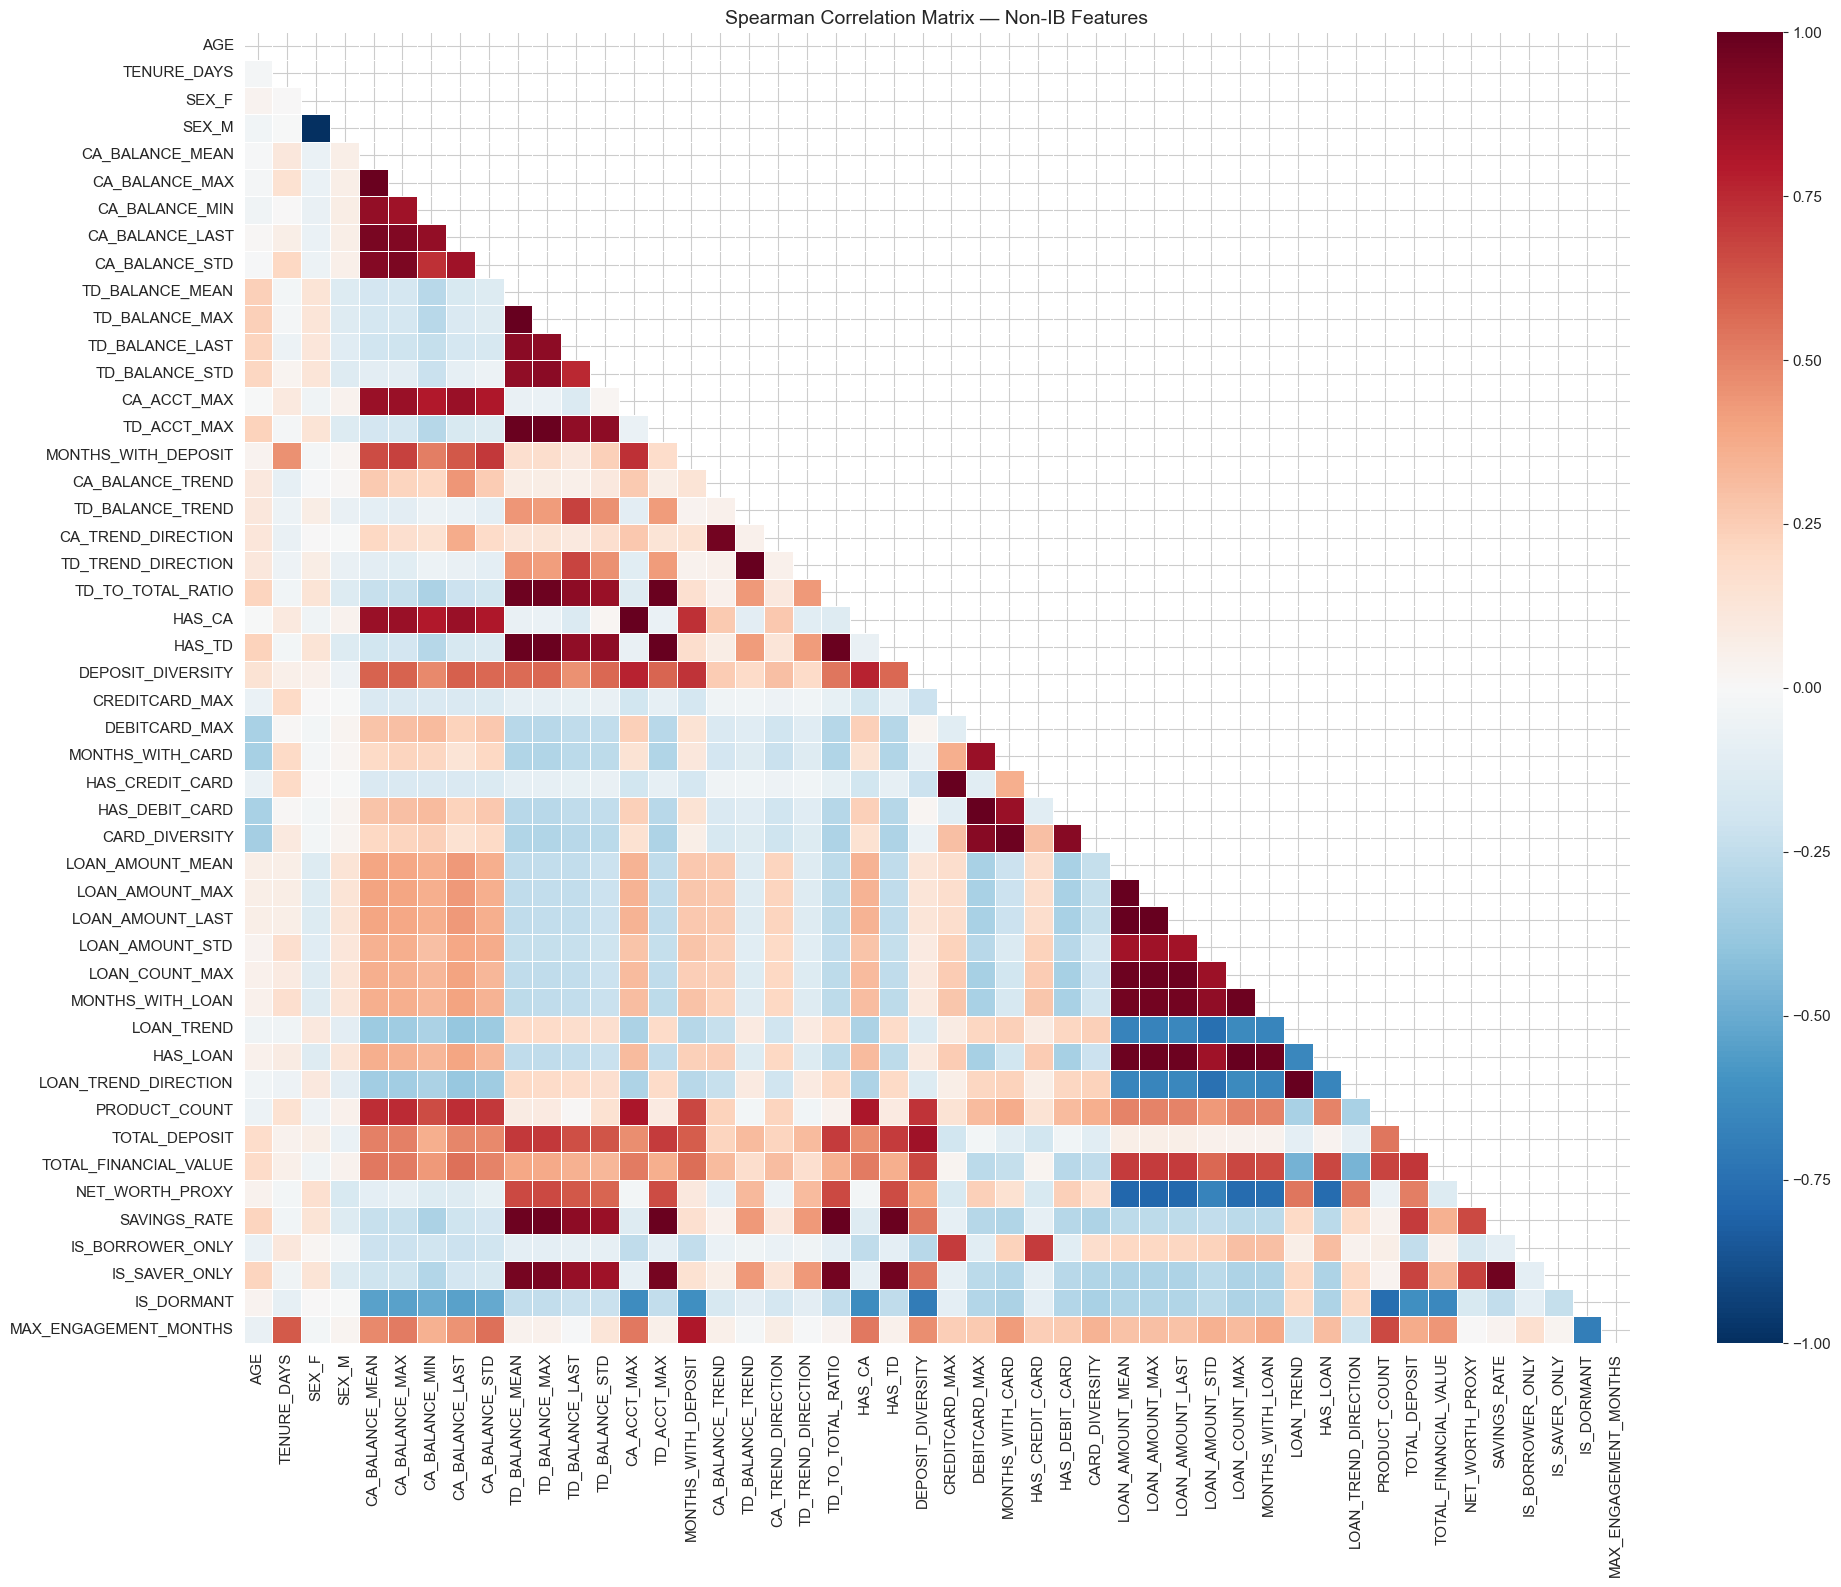


Highly correlated pairs (|r| > 0.85):


,Feature_A,Feature_B,Correlation
0,SEX_F,SEX_M,-1.000000
50,CREDITCARD_MAX,HAS_CREDIT_CARD,0.999963
57,LOAN_AMOUNT_MEAN,LOAN_AMOUNT_MAX,0.999779
58,LOAN_AMOUNT_MEAN,LOAN_AMOUNT_LAST,0.999639
62,LOAN_AMOUNT_MAX,LOAN_AMOUNT_LAST,0.999389
...,...,...,...
5,CA_BALANCE_MEAN,CA_ACCT_MAX,0.861232
13,CA_BALANCE_LAST,HAS_CA,0.860277
12,CA_BALANCE_LAST,CA_ACCT_MAX,0.860062
69,LOAN_AMOUNT_STD,LOAN_COUNT_MAX,0.854560


In [10]:
# Select numeric features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID column
numeric_cols = [c for c in numeric_cols if c != 'CUSTOMER_NUMBER']

corr = df[numeric_cols].corr(method='spearman')  # Spearman for non-linear relationships

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlation Matrix — Non-IB Features', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs (|r| > 0.85)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append({
                'Feature_A': corr.columns[i],
                'Feature_B': corr.columns[j],
                'Correlation': corr.iloc[i, j]
            })

if high_corr:
    print('\nHighly correlated pairs (|r| > 0.85):')
    display(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False))
else:
    print('No highly correlated pairs found.')

---
## 6. Bivariate Analysis — Key Relationships

Active customers: 102,430


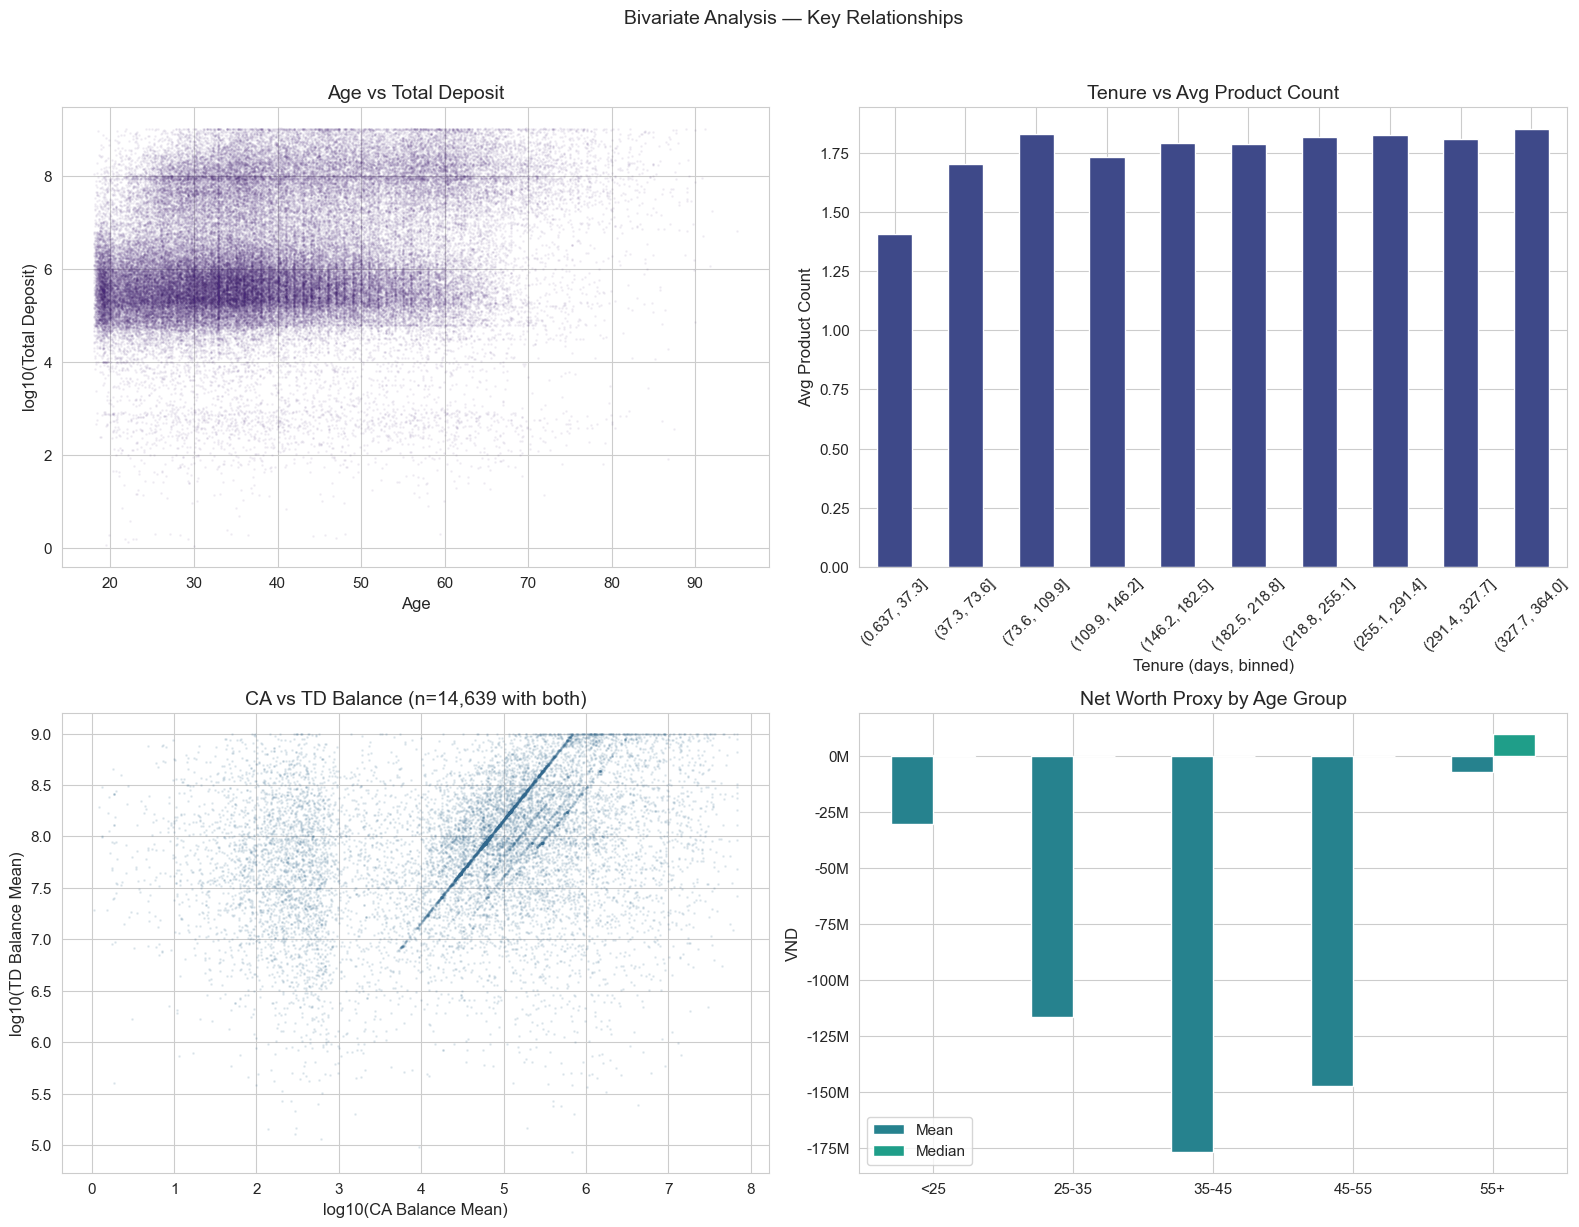

In [11]:
# Active customers only (with at least 1 product)
df_active = df[df['PRODUCT_COUNT'] > 0].copy()
print(f'Active customers: {len(df_active):,}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age vs Total Deposit
ax = axes[0, 0]
nonzero_dep = df_active[df_active['TOTAL_DEPOSIT'] > 0]
ax.scatter(nonzero_dep['AGE'], np.log10(nonzero_dep['TOTAL_DEPOSIT'] + 1),
           alpha=0.05, s=1, color=PALETTE[0])
ax.set_xlabel('Age')
ax.set_ylabel('log10(Total Deposit)')
ax.set_title('Age vs Total Deposit')

# Tenure vs Product Count
ax = axes[0, 1]
tenure_prod = df_active.groupby(pd.cut(df_active['TENURE_DAYS'], bins=10))['PRODUCT_COUNT'].mean()
tenure_prod.plot(kind='bar', ax=ax, color=PALETTE[1])
ax.set_title('Tenure vs Avg Product Count')
ax.set_xlabel('Tenure (days, binned)')
ax.set_ylabel('Avg Product Count')
ax.tick_params(axis='x', rotation=45)

# CA Balance vs TD Balance (log)
ax = axes[1, 0]
both = df_active[(df_active['CA_BALANCE_MEAN'] > 0) & (df_active['TD_BALANCE_MEAN'] > 0)]
ax.scatter(np.log10(both['CA_BALANCE_MEAN'] + 1), np.log10(both['TD_BALANCE_MEAN'] + 1),
           alpha=0.1, s=1, color=PALETTE[2])
ax.set_xlabel('log10(CA Balance Mean)')
ax.set_ylabel('log10(TD Balance Mean)')
ax.set_title(f'CA vs TD Balance (n={len(both):,} with both)')

# Net Worth by Age Group
ax = axes[1, 1]
nw_by_age = df_active.groupby('AGE_GROUP')['NET_WORTH_PROXY'].agg(['mean', 'median'])
x = range(len(nw_by_age))
ax.bar([i - 0.15 for i in x], nw_by_age['mean'], width=0.3, label='Mean', color=PALETTE[3])
ax.bar([i + 0.15 for i in x], nw_by_age['median'], width=0.3, label='Median', color=PALETTE[4])
ax.set_xticks(list(x))
ax.set_xticklabels(nw_by_age.index.astype(str))
ax.set_title('Net Worth Proxy by Age Group')
ax.set_ylabel('VND')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.suptitle('Bivariate Analysis — Key Relationships', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Outlier Analysis

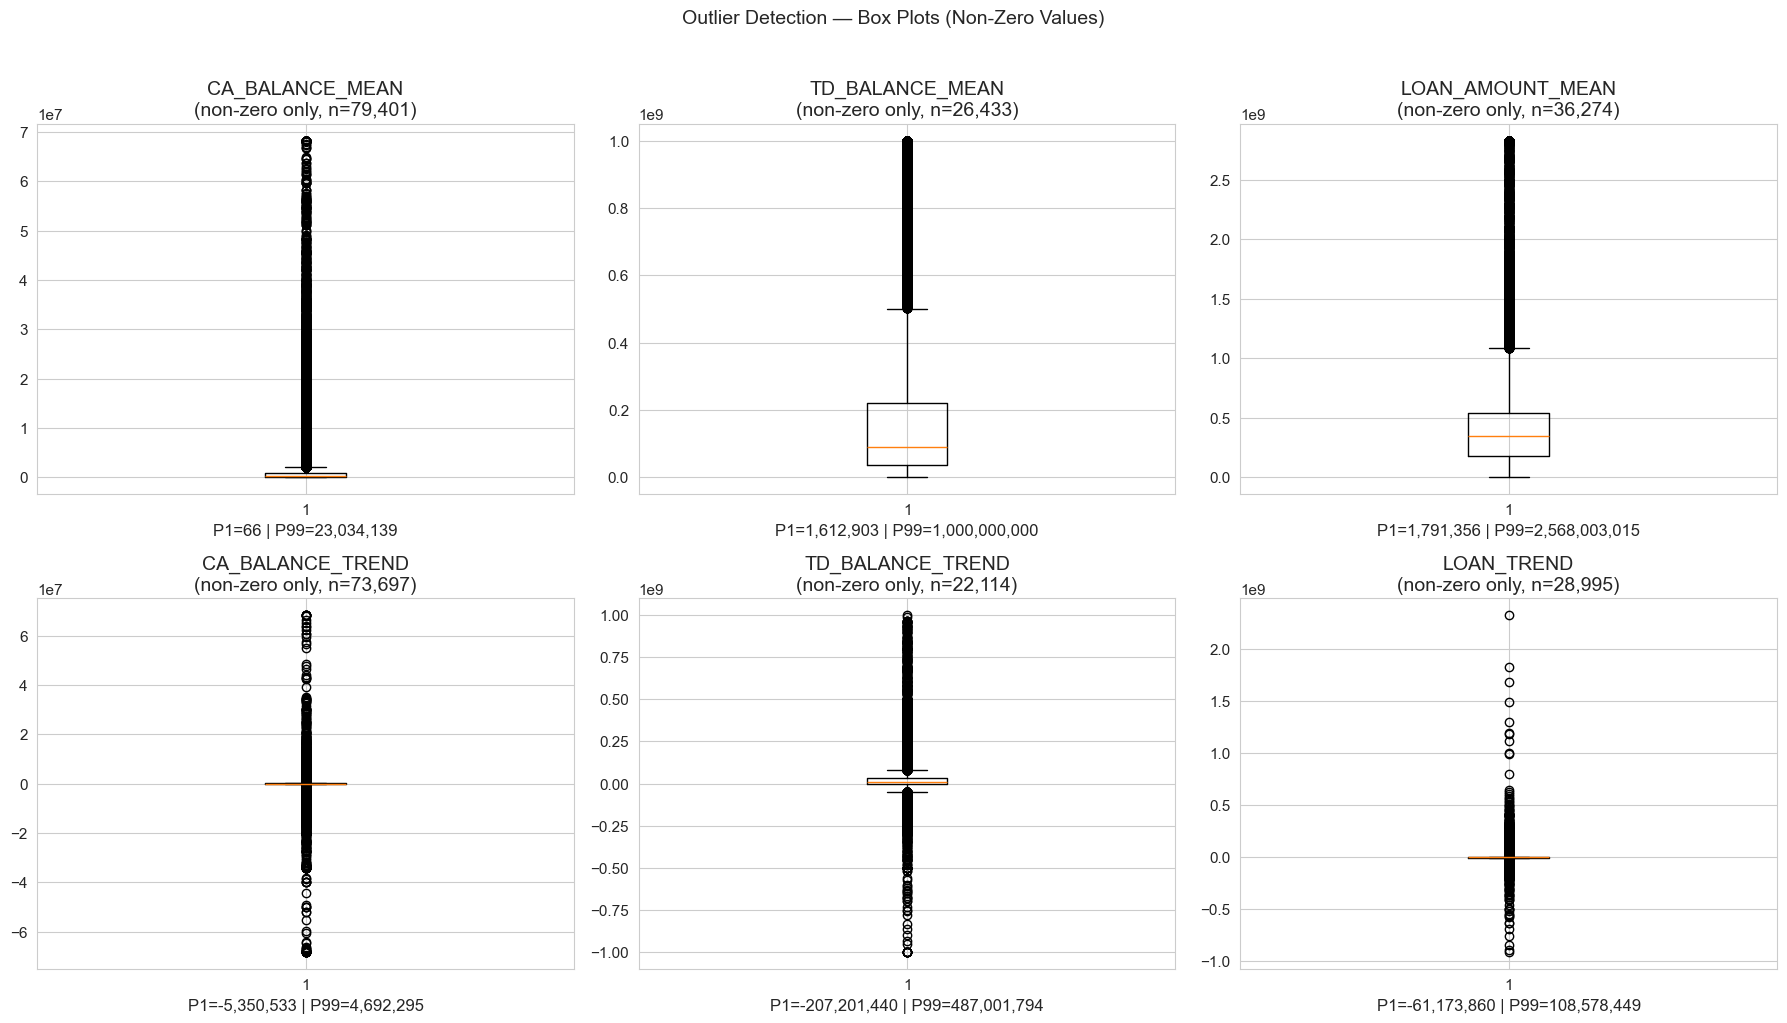

Outlier counts (IQR method, >1.5*IQR):
  CA_BALANCE_MEAN: 12,840 outliers (12.5%)
  TD_BALANCE_MEAN: 24,156 outliers (23.6%)
  LOAN_AMOUNT_MEAN: 9,940 outliers (9.7%)
  CA_BALANCE_TREND: 29,983 outliers (29.3%)
  TD_BALANCE_TREND: 22,114 outliers (21.6%)
  LOAN_TREND: 28,864 outliers (28.2%)


In [12]:
# Box plots for key monetary features
outlier_cols = ['CA_BALANCE_MEAN', 'TD_BALANCE_MEAN', 'LOAN_AMOUNT_MEAN',
                'CA_BALANCE_TREND', 'TD_BALANCE_TREND', 'LOAN_TREND']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    data = df_active[col]
    nonzero = data[data != 0]
    if len(nonzero) > 0:
        axes[i].boxplot(nonzero, vert=True)
        axes[i].set_title(f'{col}\n(non-zero only, n={len(nonzero):,})')
        # Show percentile info
        p1 = nonzero.quantile(0.01)
        p99 = nonzero.quantile(0.99)
        axes[i].set_xlabel(f'P1={p1:,.0f} | P99={p99:,.0f}')
    else:
        axes[i].set_title(f'{col}\n(all zeros)')

plt.suptitle('Outlier Detection — Box Plots (Non-Zero Values)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR outlier counts
print('Outlier counts (IQR method, >1.5*IQR):')
for col in outlier_cols:
    data = df_active[col]
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    print(f'  {col}: {n_outliers:,} outliers ({n_outliers/len(data)*100:.1f}%)')

---
## 8. Segment Overview — Dormant vs Active vs Product Types

,Segment,Count,Pct
0,Dormant (no products),24570,19.3%
1,"Saver-only (TD, no loan)",24915,19.6%
2,"Borrower-only (loan, no deposit)",4605,3.6%
3,CA-only (basic banking),34596,27.2%
4,Multi-product (3+),3532,2.8%


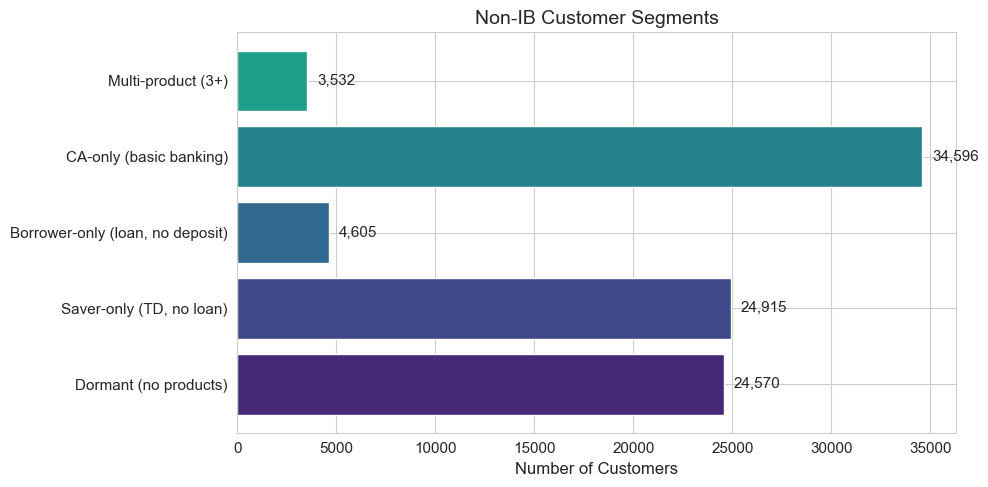

In [13]:
# Customer segmentation overview
segments = {
    'Dormant (no products)': (df['IS_DORMANT'] == 1).sum(),
    'Saver-only (TD, no loan)': (df['IS_SAVER_ONLY'] == 1).sum(),
    'Borrower-only (loan, no deposit)': (df['IS_BORROWER_ONLY'] == 1).sum(),
    'CA-only (basic banking)': ((df['HAS_CA'] == 1) & (df['HAS_TD'] == 0) & (df['HAS_LOAN'] == 0) & (df['HAS_CREDIT_CARD'] == 0)).sum(),
    'Multi-product (3+)': (df['PRODUCT_COUNT'] >= 3).sum(),
}

seg_df = pd.DataFrame([
    {'Segment': k, 'Count': v, 'Pct': f'{v/len(df)*100:.1f}%'}
    for k, v in segments.items()
])
display(seg_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(seg_df['Segment'], seg_df['Count'], color=PALETTE[:5])
ax.set_xlabel('Number of Customers')
ax.set_title('Non-IB Customer Segments')
for bar, count in zip(bars, seg_df['Count']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'segments_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Key Findings Summary

Ghi nhận các findings quan trọng trước khi đưa vào clustering.

In [14]:
print('=' * 60)
print('EDA KEY FINDINGS — NON-IB CUSTOMERS')
print('=' * 60)

print(f'''
1. DEMOGRAPHICS:
   - Median age: {df["AGE"].median():.0f} years
   - Gender split: ~50/50 (M/F) with {(df["CLIENT_SEX"] == "UNKNOWN").sum():,} unknown
   - Median tenure: {df["TENURE_DAYS"].median():.0f} days

2. PRODUCT PENETRATION:
   - {(df["IS_DORMANT"]==1).sum():,} ({(df["IS_DORMANT"]==1).mean()*100:.1f}%) customers have NO products
   - Most common: Current Account ({(df["HAS_CA"]==1).mean()*100:.1f}%)
   - Least common: Credit Card ({(df["HAS_CREDIT_CARD"]==1).mean()*100:.1f}%)

3. FINANCIAL PATTERNS:
   - CA Balance highly skewed (need log-transform for clustering)
   - TD ownership concentrated in older customers
   - Loan amounts vary widely (need capping at P99)

4. CLUSTERING PREP DECISIONS:
   - Remove dormant customers (set aside as Persona 0)
   - Log-transform monetary features
   - Cap outliers at P99
   - StandardScaler after transforms
   - Check multicollinearity: remove features with |r| > 0.95
''')

print('\n✅ Notebook 2 complete. Proceed to 03_nonib_clustering.ipynb')

EDA KEY FINDINGS — NON-IB CUSTOMERS

1. DEMOGRAPHICS:
   - Median age: 37 years
   - Gender split: ~50/50 (M/F) with 0 unknown
   - Median tenure: 177 days

2. PRODUCT PENETRATION:
   - 24,570 (19.3%) customers have NO products
   - Most common: Current Account (62.5%)
   - Least common: Credit Card (3.8%)

3. FINANCIAL PATTERNS:
   - CA Balance highly skewed (need log-transform for clustering)
   - TD ownership concentrated in older customers
   - Loan amounts vary widely (need capping at P99)

4. CLUSTERING PREP DECISIONS:
   - Remove dormant customers (set aside as Persona 0)
   - Log-transform monetary features
   - Cap outliers at P99
   - StandardScaler after transforms
   - Check multicollinearity: remove features with |r| > 0.95


✅ Notebook 2 complete. Proceed to 03_nonib_clustering.ipynb
